Loading and Scaling Optdigits Dataset...
Calculating K-Means metrics...
Calculating GMM metrics...
Calculating K-Distance Graph for DBSCAN...
Generating Dendrogram...


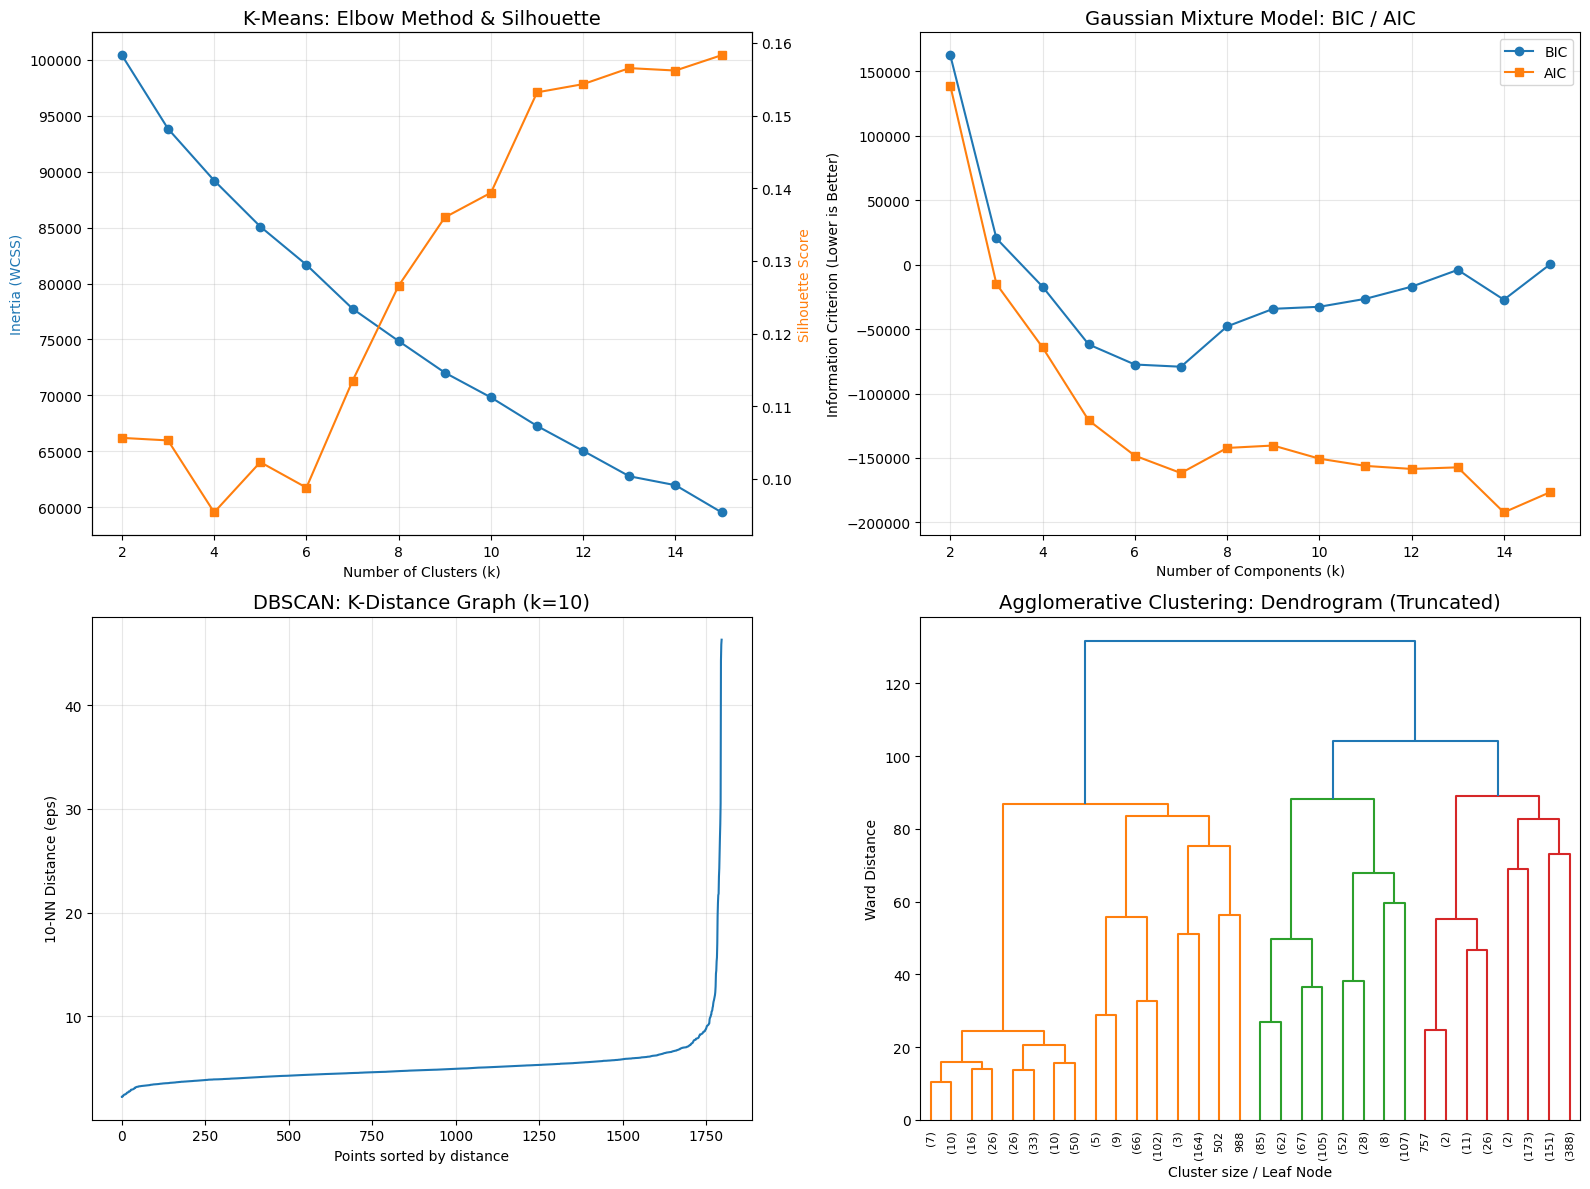

In [1]:
# --- QUESTION 4: CLUSTERING & ENSEMBLES ---

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Loading and Scaling Optdigits Dataset...")
# 1. Load Data
digits = load_digits()
# Scaling is critical for distance-based clustering (K-Means, DBSCAN, Agglomerative)
X = StandardScaler().fit_transform(digits.data)
y = digits.target # Stored strictly for external validation later

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
k_range = range(2, 16)

# 2. K-Means: Elbow Method and Silhouette Score
print("Calculating K-Means metrics...")
inertias = []
sil_scores_kmeans = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    sil_scores_kmeans.append(silhouette_score(X, labels))

ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(k_range, inertias, marker='o', color='tab:blue', label='WCSS (Elbow)')
ax1_twin.plot(k_range, sil_scores_kmeans, marker='s', color='tab:orange', label='Silhouette Score')
ax1.set_title('K-Means: Elbow Method & Silhouette', fontsize=14)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color='tab:blue')
ax1_twin.set_ylabel('Silhouette Score', color='tab:orange')
ax1.grid(True, alpha=0.3)

# 3. GMM: BIC and AIC
print("Calculating GMM metrics...")
bics = []
aics = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=RANDOM_SEED)
    gmm.fit(X)
    bics.append(gmm.bic(X))
    aics.append(gmm.aic(X))

axes[0, 1].plot(k_range, bics, marker='o', label='BIC')
axes[0, 1].plot(k_range, aics, marker='s', label='AIC')
axes[0, 1].set_title('Gaussian Mixture Model: BIC / AIC', fontsize=14)
axes[0, 1].set_xlabel('Number of Components (k)')
axes[0, 1].set_ylabel('Information Criterion (Lower is Better)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 4. DBSCAN: K-Distance Graph to find optimal eps
print("Calculating K-Distance Graph for DBSCAN...")
# Using MinPts = 2 * dimensions is a rule of thumb, but for 64D data, it's too high.
# We'll use k=10 for the nearest neighbors graph.
k_neighbors = 10
nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X)
distances, indices = nn.kneighbors(X)
# Sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, k_neighbors-1])

axes[1, 0].plot(k_distances)
axes[1, 0].set_title('DBSCAN: K-Distance Graph (k=10)', fontsize=14)
axes[1, 0].set_xlabel('Points sorted by distance')
axes[1, 0].set_ylabel(f'{k_neighbors}-NN Distance (eps)')
axes[1, 0].grid(True, alpha=0.3)

# 5. Agglomerative: Dendrogram with Ward Linkage
print("Generating Dendrogram...")
Z = linkage(X, method='ward')
axes[1, 1].set_title('Agglomerative Clustering: Dendrogram (Truncated)', fontsize=14)
dendrogram(Z, truncate_mode='level', p=4, ax=axes[1, 1], leaf_rotation=90)
axes[1, 1].set_xlabel('Cluster size / Leaf Node')
axes[1, 1].set_ylabel('Ward Distance')

plt.tight_layout()
plt.show()

Running Final Clustering Models...
Running Stability Analysis (5 bootstraps)...

--- Average Stability Scores (ARI) ---
K-Means (k=10): 0.5041
GMM (k=10): 0.4915
Agglomerative (k=10): 0.5365
DBSCAN (eps=7.5): 0.0004

Building Cluster Ensemble (Co-association Matrix)...

--- Final Metric Comparison ---


,Model,Silhouette,CH Score,DB Index,ARI,NMI,FMI
0,K-Means (k=10),0.1394,113.2043,1.8770,0.5344,0.6712,0.5912
1,GMM (k=10),0.1179,102.5776,2.0029,0.5467,0.6902,0.6055
2,Agglomerative (k=10),0.1253,105.8252,1.9672,0.6643,0.7956,0.7111
3,DBSCAN (eps=7.5),0.5163,39.5600,3.5218,0.0003,0.0111,0.3079
4,Ensemble (Co-association),NaN,NaN,NaN,0.5495,0.6879,0.6053



Generating UMAP Visualizations...


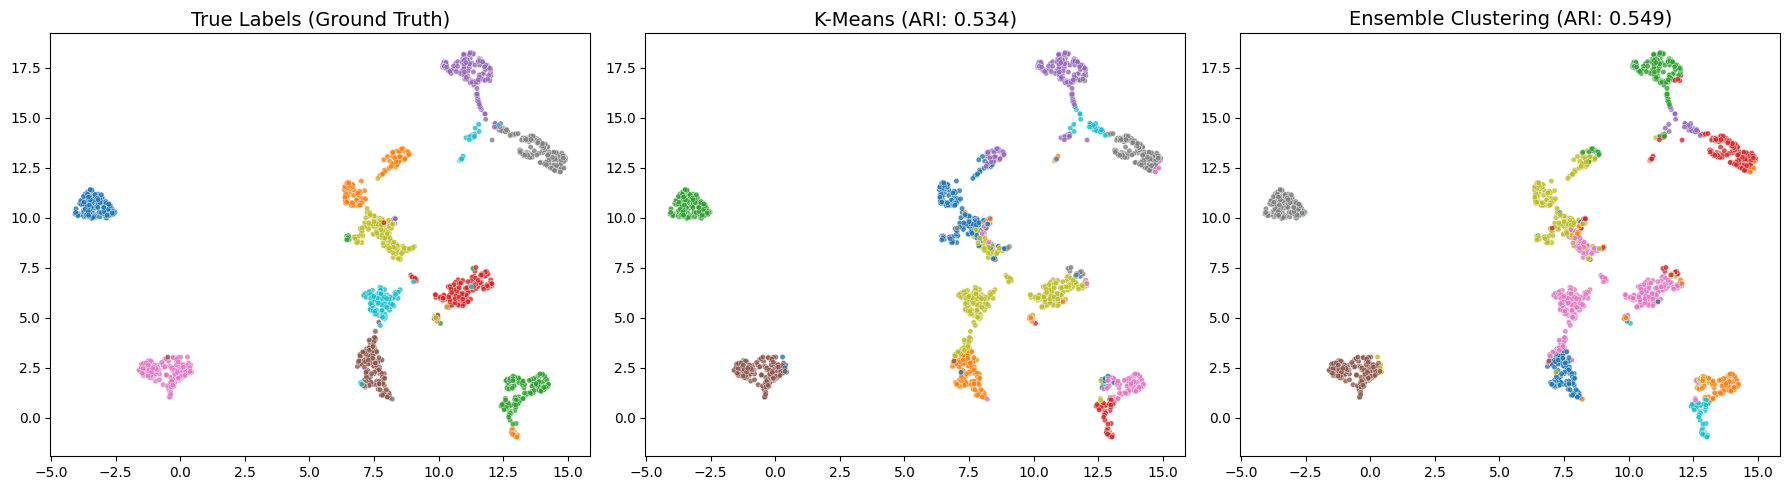

In [2]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.utils import resample
import pandas as pd
import umap

print("Running Final Clustering Models...")

# 1. Define the models based on our hyperparameter visualisations
models = {
    'K-Means (k=10)': KMeans(n_clusters=10, random_state=RANDOM_SEED, n_init=10),
    'GMM (k=10)': GaussianMixture(n_components=10, random_state=RANDOM_SEED),
    'Agglomerative (k=10)': AgglomerativeClustering(n_clusters=10, linkage='ward'),
    'DBSCAN (eps=7.5)': DBSCAN(eps=7.5, min_samples=10)
}

results = []
labels_dict = {}

# 2. Evaluate Internal and External Metrics
for name, model in models.items():
    labels = model.fit_predict(X)
    labels_dict[name] = labels

    # Internal Metrics (Handle DBSCAN's noise output gracefully)
    if len(set(labels)) > 1:
        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db_idx = davies_bouldin_score(X, labels)
    else:
        sil, ch, db_idx = np.nan, np.nan, np.nan

    # External Metrics (Since we have the ground truth 'y')
    ari = adjusted_rand_score(y, labels)
    nmi = normalized_mutual_info_score(y, labels)
    fmi = fowlkes_mallows_score(y, labels)

    results.append({
        'Model': name, 'Silhouette': sil, 'CH Score': ch, 'DB Index': db_idx,
        'ARI': ari, 'NMI': nmi, 'FMI': fmi
    })

# 3. Cluster Stability Analysis (80% Subsampling)
print("Running Stability Analysis (5 bootstraps)...")
stability_scores = {name: [] for name in models.keys()}

for i in range(5):
    # Subsample 80% of the data
    X_sub, y_sub = resample(X, y, n_samples=int(0.8 * len(X)), random_state=RANDOM_SEED+i)

    for name, model in models.items():
        if name.startswith('GMM'):
            sub_labels = GaussianMixture(n_components=10, random_state=RANDOM_SEED+i).fit_predict(X_sub)
        elif name.startswith('K-Means'):
            sub_labels = KMeans(n_clusters=10, random_state=RANDOM_SEED+i, n_init=10).fit_predict(X_sub)
        elif name.startswith('Agglomerative'):
            sub_labels = AgglomerativeClustering(n_clusters=10, linkage='ward').fit_predict(X_sub)
        else:
            sub_labels = DBSCAN(eps=7.5, min_samples=10).fit_predict(X_sub)

        # Calculate ARI against the true labels of the subsample to measure stability
        stability_scores[name].append(adjusted_rand_score(y_sub, sub_labels))

print("\n--- Average Stability Scores (ARI) ---")
for name, scores in stability_scores.items():
    print(f"{name}: {np.mean(scores):.4f}")

# 4. Cluster Ensemble (Co-association Matrix)
print("\nBuilding Cluster Ensemble (Co-association Matrix)...")
# We combine variations of K-Means, GMM, and DBSCAN as requested
ensemble_labels_list = [
    KMeans(n_clusters=9, random_state=RANDOM_SEED, n_init=10).fit_predict(X),
    KMeans(n_clusters=10, random_state=RANDOM_SEED, n_init=10).fit_predict(X),
    KMeans(n_clusters=11, random_state=RANDOM_SEED, n_init=10).fit_predict(X),
    GaussianMixture(n_components=10, random_state=RANDOM_SEED).fit_predict(X),
    DBSCAN(eps=7.5, min_samples=10).fit_predict(X)
]

n_samples = X.shape[0]
co_matrix = np.zeros((n_samples, n_samples))

# Build the matrix: +1 every time two points share the same cluster
for labels in ensemble_labels_list:
    # Vectorized comparison: creates an NxN boolean matrix of matches
    mask = (labels[:, None] == labels[None, :]) & (labels[:, None] != -1) # Ignore DBSCAN noise (-1)
    co_matrix += mask.astype(int)

# Convert the similarity matrix into a distance matrix
distance_matrix = 1.0 - (co_matrix / len(ensemble_labels_list))

# Run Agglomerative Clustering on the new distance matrix to get final ensemble votes
ensemble_model = AgglomerativeClustering(n_clusters=10, metric='precomputed', linkage='average')
final_ensemble_labels = ensemble_model.fit_predict(distance_matrix)

ens_ari = adjusted_rand_score(y, final_ensemble_labels)
ens_nmi = normalized_mutual_info_score(y, final_ensemble_labels)
results.append({
    'Model': 'Ensemble (Co-association)', 'Silhouette': np.nan, 'CH Score': np.nan, 'DB Index': np.nan,
    'ARI': ens_ari, 'NMI': ens_nmi, 'FMI': fowlkes_mallows_score(y, final_ensemble_labels)
})

print("\n--- Final Metric Comparison ---")
display(pd.DataFrame(results).round(4))

# 5. Visualise Clusters using UMAP Projections
print("\nGenerating UMAP Visualizations...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
X_umap_c = reducer.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette("tab10", 10)

sns.scatterplot(x=X_umap_c[:,0], y=X_umap_c[:,1], hue=y, palette=palette, legend=False, s=15, alpha=0.8, ax=axes[0])
axes[0].set_title('True Labels (Ground Truth)', fontsize=14)

sns.scatterplot(x=X_umap_c[:,0], y=X_umap_c[:,1], hue=labels_dict['K-Means (k=10)'], palette=palette, legend=False, s=15, alpha=0.8, ax=axes[1])
axes[1].set_title(f"K-Means (ARI: {results[0]['ARI']:.3f})", fontsize=14)

sns.scatterplot(x=X_umap_c[:,0], y=X_umap_c[:,1], hue=final_ensemble_labels, palette=palette, legend=False, s=15, alpha=0.8, ax=axes[2])
axes[2].set_title(f"Ensemble Clustering (ARI: {ens_ari:.3f})", fontsize=14)

plt.tight_layout()
plt.show()